# Phân tích Khám phá Tuyển sinh Đại học Việt Nam (EDA)
## Notebook 04: Phân tích theo Nhóm ngành học

Notebook này thực hiện:
1. Phân nhóm điểm chuẩn trung bình theo từng Nhóm ngành (major_group).
2. Thống kê số lượng ngành tuyển sinh và biến động điểm chuẩn theo từng nhóm.
3. Khảo sát nhóm ngành có điểm chuẩn biến động tăng/giảm mạnh nhất.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/admission_processed.csv", encoding="utf-8-sig")

### 1. Thống kê điểm chuẩn trung bình của các nhóm ngành

In [2]:
group_stats = df.groupby('major_group')['admission_score'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_values('mean', ascending=False).reset_index()
print(group_stats.round(2))

             major_group  count   mean  median   std   min    max
0     Sư phạm - Giáo dục  10614  25.43   25.83  2.42  14.0  30.00
1          Luật - Xã hội   6342  21.04   22.22  4.01  14.0  30.00
2                   Khác  47772  19.73   19.50  4.22  14.0  30.00
3     Kinh tế - Quản trị  44352  19.47   18.92  4.18  13.0  30.00
4  Nghệ thuật - Nhân văn  12360  19.38   18.46  4.17  14.0  30.00
5               Y - Dược   5010  19.30   19.00  2.85  14.0  30.00
6   Kỹ thuật - Công nghệ  58680  19.05   18.24  3.94  13.0  30.00
7       Nông - Lâm - Ngư   2544  16.71   15.67  2.40  14.0  25.48


/tmp/ipykernel_57761/674342935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='major_group', y='admission_score', data=df, palette='Set3')


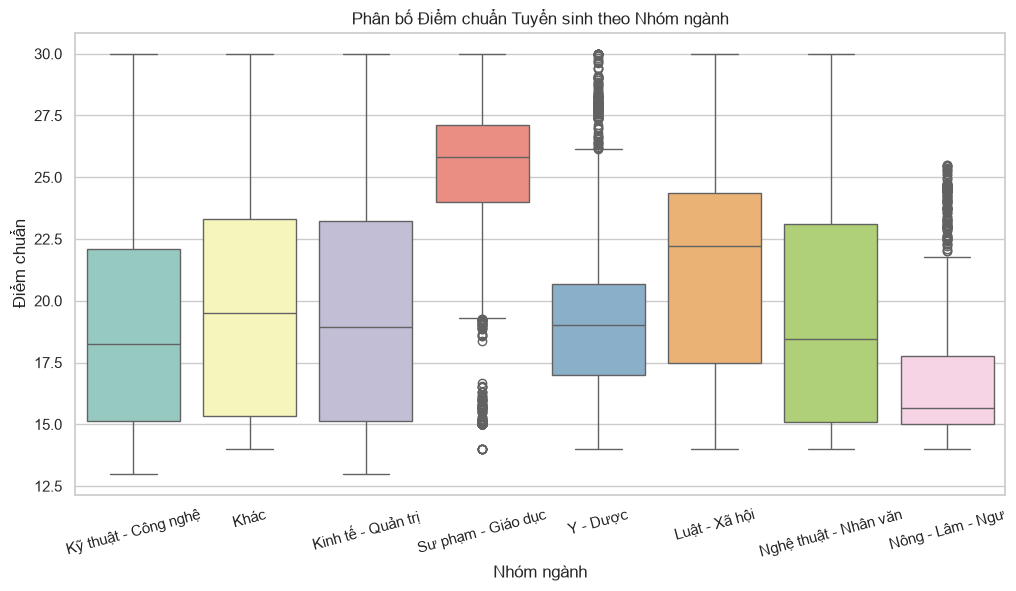

In [3]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='major_group', y='admission_score', data=df, palette='Set3')
plt.title('Phân bố Điểm chuẩn Tuyển sinh theo Nhóm ngành')
plt.xlabel('Nhóm ngành')
plt.ylabel('Điểm chuẩn')
plt.xticks(rotation=15)
plt.show()

### 2. Sự thay đổi điểm chuẩn qua các năm của các nhóm ngành

In [4]:
yearly_group_avg = df.groupby(['year', 'major_group'])['admission_score'].mean().unstack()
print(yearly_group_avg.round(2))

major_group   Khác  Kinh tế - Quản trị  Kỹ thuật - Công nghệ  Luật - Xã hội  \
year                                                                          
2020         19.84               19.58                 19.17          21.17   
2021         20.31               20.05                 19.63          21.65   
2022         19.33               19.09                 18.67          20.59   
2023         19.53               19.28                 18.86          20.83   
2024         19.67               19.41                 19.01          20.99   
2025         19.68               19.40                 18.98          21.00   

major_group  Nghệ thuật - Nhân văn  Nông - Lâm - Ngư  Sư phạm - Giáo dục  \
year                                                                       
2020                         19.49             16.81               25.56   
2021                         19.97             17.28               25.96   
2022                         19.00             16.39           

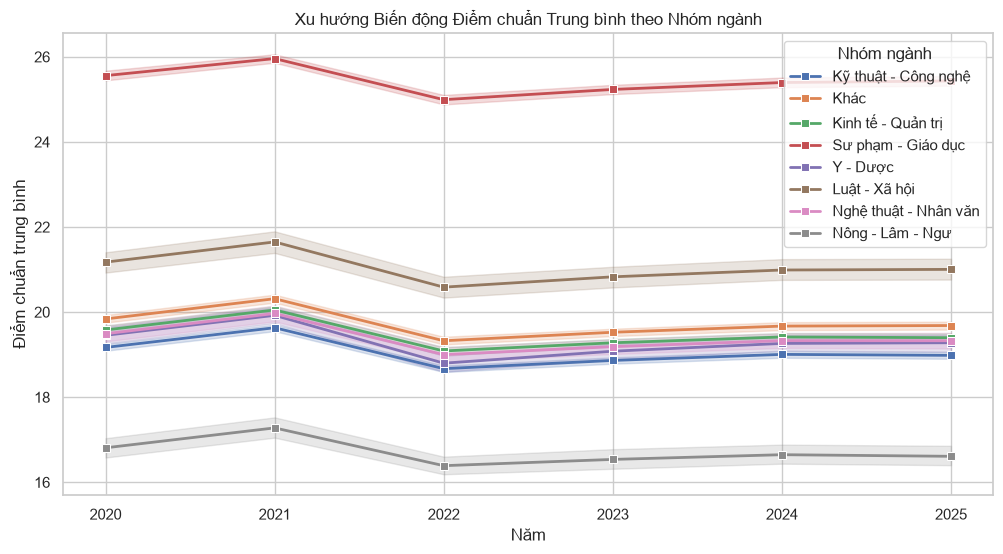

In [5]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='admission_score', hue='major_group', data=df, marker='s', linewidth=2.0)
plt.title('Xu hướng Biến động Điểm chuẩn Trung bình theo Nhóm ngành')
plt.xlabel('Năm')
plt.ylabel('Điểm chuẩn trung bình')
plt.legend(title='Nhóm ngành')
plt.show()